In [11]:
import os
import cv2
import numpy as np
import pandas as pd
from datetime import datetime


In [12]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [13]:
# ---------------- CONFIGURACIÓN ----------------

IMG_HEIGHT = 128
IMG_WIDTH = 128
SEQ_LENGTH = 5

BASE_DIR = "/content/drive/MyDrive/Datasets/PIA/Inundaciones/River/FarsonDigital_CameraImages_NovDec2012/"

CSV_PATH = "/content/drive/MyDrive/Datasets/PIA/Inundaciones/labels.csv"

CAMERAS = [
    "TewkesburyCamera",
    "StrenshamLockCamera",
    "EveshamCamera",
    "DiglisLockCamera"
]

# ------------------------------------------------

def load_and_sort_images(directory):
    files = os.listdir(directory)
    dataset = []

    for file in files:
        if file.endswith(".jpg"):
            try:
                time_str = file.replace("y_", "-") \
                               .replace("m_", "-") \
                               .replace("d_", " ") \
                               .replace("h.jpg", "")

                date_time_obj = datetime.strptime(time_str, "%Y-%m-%d %H")
                dataset.append((date_time_obj, file))
            except:
                continue

    dataset.sort(key=lambda x: x[0])
    return dataset


def create_sequences(image_files, directory, camera_name, label_dict):
    X = []
    Y = []
    images_data = []
    valid_files = [] # Guardamos los nombres para buscar sus etiquetas después

    for _, file in image_files:
        img_path = os.path.join(directory, file)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = img / 255.0
        images_data.append(img)
        valid_files.append(file)

    # Iteramos para crear las secuencias
    # +1 para no perder la última secuencia posible
    for i in range(len(images_data) - SEQ_LENGTH + 1):
        seq_files = valid_files[i:i+SEQ_LENGTH]
        target_file = seq_files[-1] # La etiqueta de la secuencia es el estado de la última imagen

        # Comprobamos si la imagen objetivo está en nuestro CSV de etiquetas
        if (camera_name, target_file) in label_dict:
            seq = images_data[i:i+SEQ_LENGTH]
            X.append(seq)
            Y.append(label_dict[(camera_name, target_file)])

    return np.array(X), np.array(Y)


# ---------------- PROCESO GLOBAL ----------------

# 1. Cargar el CSV con las etiquetas reales
df_labels = pd.read_csv(CSV_PATH)
print(f"Cargadas {len(df_labels)} etiquetas desde el CSV.")

# Crear un diccionario para búsquedas súper rápidas: {(camera, filename): label}
label_dict = {}
for index, row in df_labels.iterrows():
    label_dict[(row['camera'], row['filename'])] = row['label']

X_total = []
Y_total = []

for cam in CAMERAS:
    cam_dir = os.path.join(BASE_DIR, cam)
    print(f"\nProcesando cámara: {cam}")

    if not os.path.exists(cam_dir):
        print("  Directorio no encontrado, saltando...")
        continue

    image_files = load_and_sort_images(cam_dir)
    print(f"  Imágenes encontradas: {len(image_files)}")

    # Pasamos el nombre de la cámara y nuestro diccionario de etiquetas
    X_cam, Y_cam = create_sequences(image_files, cam_dir, cam, label_dict)

    print(f"  Secuencias VÁLIDAS generadas (con etiqueta en CSV): {X_cam.shape[0] if len(X_cam) > 0 else 0}")

    if len(X_cam) > 0:
        X_total.append(X_cam)
        Y_total.append(Y_cam)


# Unimos todas las cámaras
X = np.concatenate(X_total, axis=0)
Y = np.concatenate(Y_total, axis=0)

print("\n============================")
print("DATASET FINAL")
print("Total de secuencias (X):", X.shape)
print("Total de etiquetas (Y):", Y.shape)
print("============================")

Cargadas 559 etiquetas desde el CSV.

Procesando cámara: TewkesburyCamera
  Imágenes encontradas: 138
  Secuencias VÁLIDAS generadas (con etiqueta en CSV): 134

Procesando cámara: StrenshamLockCamera
  Imágenes encontradas: 144
  Secuencias VÁLIDAS generadas (con etiqueta en CSV): 140

Procesando cámara: EveshamCamera
  Imágenes encontradas: 134
  Secuencias VÁLIDAS generadas (con etiqueta en CSV): 130

Procesando cámara: DiglisLockCamera
  Imágenes encontradas: 140
  Secuencias VÁLIDAS generadas (con etiqueta en CSV): 136

DATASET FINAL
Total de secuencias (X): (540, 5, 128, 128, 3)
Total de etiquetas (Y): (540,)


In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Dropout

def build_model():
    model = Sequential()

    # 1. Extractor de características visuales (CNN) distribuido en el tiempo
    model.add(TimeDistributed(Conv2D(32, (3, 3), activation='relu'),
                              input_shape=(SEQ_LENGTH, IMG_HEIGHT, IMG_WIDTH, 3)))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))

    model.add(TimeDistributed(Conv2D(64, (3, 3), activation='relu')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))

    model.add(TimeDistributed(Conv2D(128, (3, 3), activation='relu')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))

    model.add(TimeDistributed(Flatten()))

    # 2. Análisis temporal (LSTM)
    model.add(LSTM(64, return_sequences=False))
    model.add(Dropout(0.3)) # Prevenir sobreajuste

    # 3. Clasificador final (3 clases: Normal, Precaución, Alerta/Desbordamiento)
    model.add(Dense(32, activation='relu'))
    model.add(Dense(3, activation='softmax')) # Softmax para clasificación multiclase

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

modelo_preventivo = build_model()
modelo_preventivo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_7              │ (None, 5, 126, 126,    │           896 │
│ (TimeDistributed)               │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 5, 63, 63, 32)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 5, 61, 61, 64)  │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 5, 30, 30, 64)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 5, 28, 28, 128) │        73,856 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_12             │ (None, 5, 14, 14, 128) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_13             │ (None, 5, 25088)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │     6,439,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,534,595 (24.93 MB)

 Trainable params: 6,534,595 (24.93 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight


# 1. Función para aumentar secuencias respetando el tiempo
def aumentar_secuencias_minoritarias(X_train, y_train):
    X_aug = []
    y_aug = []

    for i in range(len(X_train)):
        secuencia = X_train[i]
        etiqueta = y_train[i]

        # Vamos a multiplicar artificialmente la clase 1 (Precaución) y la 0 (Normal)
        # para que alcancen a los de Desborde (clase 2)
        if etiqueta == 1:
            # A) Flip Horizontal (Efecto espejo aplicado a las 5 imágenes a la vez)
            # axis=2 corresponde al ancho (Width) en (Seq, Height, Width, Channels)
            seq_flipped = np.flip(secuencia, axis=2)
            X_aug.append(seq_flipped)
            y_aug.append(etiqueta)

            # B) Variar el Brillo a la secuencia original (Mismo cambio para las 5)
            # Aumenta o disminuye el brillo hasta un 30%
            factor_brillo = np.random.uniform(0.7, 1.3)
            # Usamos clip para que los pixeles no pasen de 1.0 (ya que dividiste por 255)
            seq_brillo = np.clip(secuencia * factor_brillo, 0.0, 1.0)
            X_aug.append(seq_brillo)
            y_aug.append(etiqueta)

        elif etiqueta == 0:
            # Para la clase Normal, solo añadimos un poco de ruido por brillo
            factor_brillo = np.random.uniform(0.8, 1.2)
            seq_brillo = np.clip(secuencia * factor_brillo, 0.0, 1.0)
            X_aug.append(seq_brillo)
            y_aug.append(etiqueta)
    # Si generamos nuevas imágenes, las unimos al dataset principal de entrenamiento
    if len(X_aug) > 0:
        X_train = np.concatenate((X_train, np.array(X_aug)), axis=0)
        y_train = np.concatenate((y_train, np.array(y_aug)), axis=0)

    return X_train, y_train

# 2. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, shuffle=True, stratify=Y)
print("Antes del Data Augmentation (Train):")
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

# 3. ¡AQUÍ APLICAMOS LA MAGIA DEL AUGMENTATION! Sólo en Entrenamiento
X_train, y_train = aumentar_secuencias_minoritarias(X_train, y_train)
print("\nDespués del Data Augmentation (Train):")
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

# 4. Calculamos los pesos base balanceados por cantidad
pesos_base = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)

# 5. Aplicamos un "Factor de Riesgo" manual
# Queremos que fallar en Precaución(1) o Desborde(2) duplique o triplique el castigo al modelo.
factor_riesgo = {
    0: 1.0,  # Normal: peso normal
    1: 2.5,  # Precaución: Multiplicamos el peso x2.5 (Evita que pase a "Normal")
    2: 3.0   # Desborde: Multiplicamos el peso x3.0 (Prioridad máxima)
}

# 6. Creamos el diccionario final combinando ambos
pesos_diccionario = {}
for i, peso in enumerate(pesos_base):
    pesos_diccionario[i] = peso * factor_riesgo[i]
print("\nPesos AUTOMÁTICOS:", dict(enumerate(pesos_base)))
print("\nPesos PREVENTIVOS asignados:", pesos_diccionario)

history = modelo_preventivo.fit(
    X_train, y_train,
    epochs=15,
    batch_size=8,
    validation_data=(X_test, y_test),
    class_weight=pesos_diccionario
)

Antes del Data Augmentation (Train):
{np.int64(0): np.int64(129), np.int64(1): np.int64(81), np.int64(2): np.int64(222)}

Después del Data Augmentation (Train):
{np.int64(0): np.int64(258), np.int64(1): np.int64(243), np.int64(2): np.int64(222)}

Pesos AUTOMÁTICOS: {0: np.float64(0.9341085271317829), 1: np.float64(0.9917695473251029), 2: np.float64(1.0855855855855856)}

Pesos PREVENTIVOS asignados: {0: np.float64(0.9341085271317829), 1: np.float64(2.4794238683127574), 2: np.float64(3.256756756756757)}
Epoch 1/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.3969 - loss: 2.1522 - val_accuracy: 0.8241 - val_loss: 0.4516
Epoch 2/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.7921 - loss: 0.9310 - val_accuracy: 0.8611 - val_loss: 0.3143
Epoch 3/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.8768 - loss: 0.6115 - val_accuracy: 0.8981 - val_loss: 0.2671
Epoch 4/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.9221 - loss: 0.4088 - val_accuracy: 0.9167 - va

In [16]:
def evaluar_riesgo_preventivo(secuencia_ultimas_5_horas, modelo):
    secuencia = np.expand_dims(secuencia_ultimas_5_horas, axis=0)

    # Devuelve probabilidades ej: [[0.70, 0.20, 0.10]]
    prediccion = modelo.predict(secuencia, verbose=0)[0]

    prob_normal = prediccion[0]
    prob_precaucion = prediccion[1]
    prob_desborde = prediccion[2]

    # --- UMBRALES PREVENTIVOS ---
    # Si la probabilidad de desborde es mayor al 25%, declaramos emergencia
    # sin importar lo que opine la clase "normal"
    if prob_desborde > 0.25:
        print(f"[PREVENTIVO - {prob_desborde*100:.1f}%] 🚨 ALERTA ROJA 🚨: Probable desbordamiento inminente.")
        return 2

    # Si el desborde no es alto, pero la precaución y desborde sumados son inquietantes
    elif (prob_precaucion + prob_desborde) > 0.35:
        print(f"[PREVENTIVO - {(prob_precaucion)*100:.1f}%] AVISO: Nivel de agua sospechoso. Precaución.")
        return 1

    # Solo si estamos MUY seguros de que no pasa nada, declaramos Normal
    else:
        print(f"[Seguro - {prob_normal*100:.1f}%] Estado Normal. No hay peligro.")
        return 0

In [17]:
import matplotlib.pyplot as plt

# 1. Definimos el diccionario para traducir las etiquetas a texto
label_to_text = {
    0: "Normal",
    1: "Precaución",
    2: "Desborde"
}

if len(X_test) > 0:
    # 2. Generamos las predicciones con el conjunto de test
    predicciones_prob = modelo_preventivo.predict(X_test)
    predicted_classes = np.argmax(predicciones_prob, axis=1)

    # ------------------ NUEVO BLOQUE: ACIERTOS POR CATEGORÍA ------------------
    print("\n=============================================")
    print("       RESUMEN DE ACIERTOS POR CLASE")
    print("=============================================")

    # Inicializamos contadores para cada clase
    totales_por_clase = {0: 0, 1: 0, 2: 0}
    aciertos_por_clase = {0: 0, 1: 0, 2: 0}

    # Contamos los totales y los aciertos comparando la realidad (y_test) con la predicción
    for real, pred in zip(y_test, predicted_classes):
        totales_por_clase[real] += 1
        if real == pred:
            aciertos_por_clase[real] += 1

    # Imprimimos los resultados calculando el porcentaje
    for clase, nombre in label_to_text.items():
        total = totales_por_clase[clase]
        aciertos = aciertos_por_clase[clase]

        if total > 0:
            porcentaje = (aciertos / total) * 100
            print(f"🔸 {nombre.upper():<12} -> Acertó {aciertos:2d} de {total:2d}  ({porcentaje:.1f}%)")
        else:
            print(f"🔸 {nombre.upper():<12} -> No hay datos etiquetados de esta clase en el Test.")

    print("=============================================\n")
    # --------------------------------------------------------------------------

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step

       RESUMEN DE ACIERTOS POR CLASE
🔸 NORMAL       -> Acertó 32 de 32  (100.0%)
🔸 PRECAUCIÓN   -> Acertó 19 de 21  (90.5%)
🔸 DESBORDE     -> Acertó 51 de 55  (92.7%)



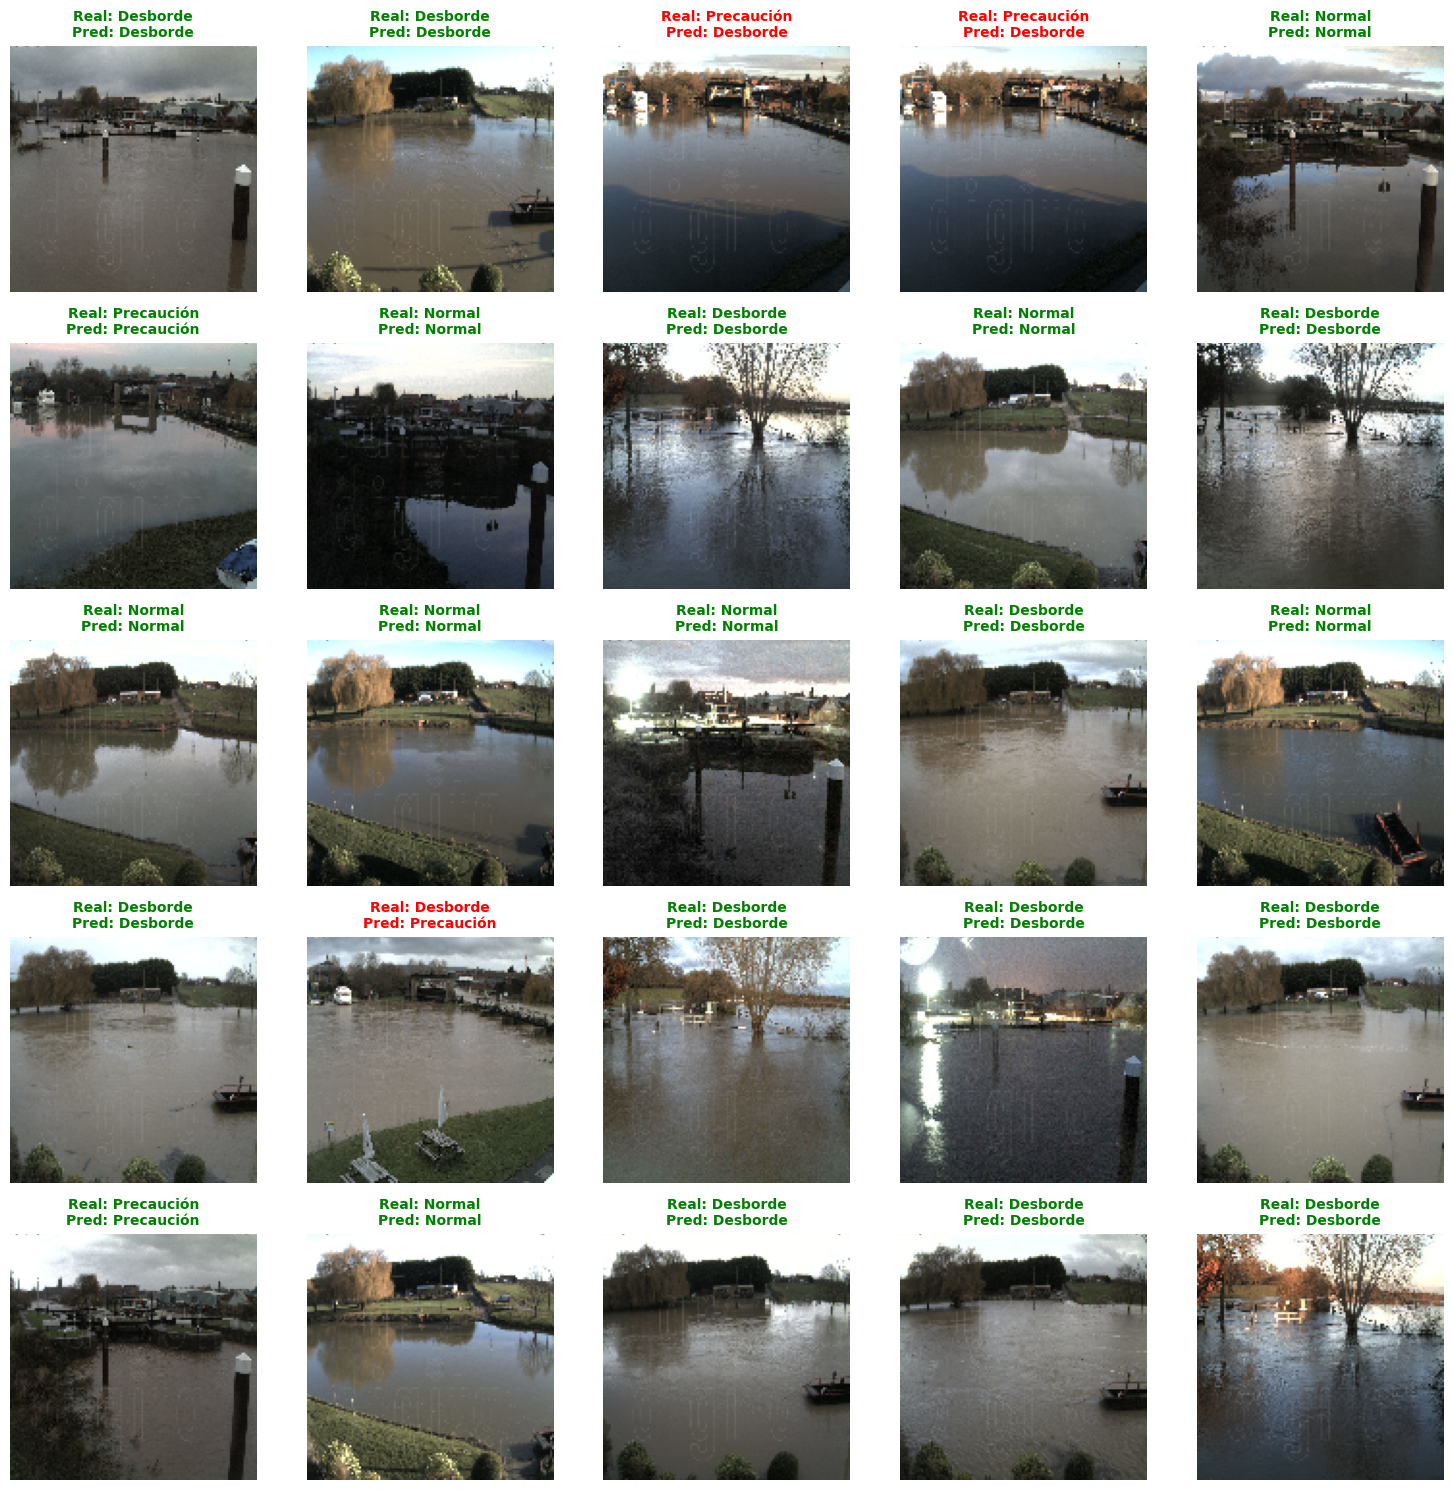

In [18]:
# 3. Mostrar una matriz de 5x5 con la etiqueta verdadera y predicha
if len(X_test) > 0:
    plt.figure(figsize=(15, 15))

    num_imagenes = min(25, len(X_test))

    for i in range(num_imagenes):
        plt.subplot(5, 5, i + 1)

        ultima_imagen = X_test[i][-1]
        plt.imshow(ultima_imagen[:, :, ::-1])

        true_label = label_to_text[y_test[i]]
        predicted_label = label_to_text[predicted_classes[i]]

        color_titulo = 'green' if true_label == predicted_label else 'red'

        plt.title(f"Real: {true_label}\nPred: {predicted_label}", color=color_titulo, fontsize=10, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("\nNo hay suficientes datos etiquetados para mostrar las predicciones de Test.")

In [19]:
unique, counts = np.unique(y_train, return_counts=True)
print("Distribución en ENTRENAMIENTO (Train):", dict(zip(unique, counts)))

Distribución en ENTRENAMIENTO (Train): {np.int64(0): np.int64(258), np.int64(1): np.int64(243), np.int64(2): np.int64(222)}


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


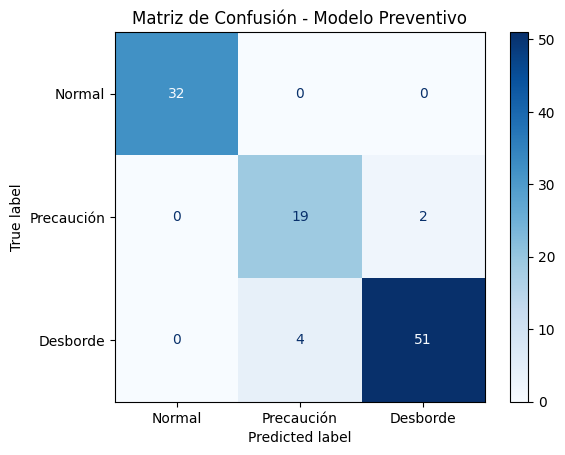

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

predicciones = np.argmax(modelo_preventivo.predict(X_test), axis=1)

cm = confusion_matrix(y_test, predicciones)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Precaución", "Desborde"])
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusión - Modelo Preventivo")
plt.show()